In [183]:
import yaml
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Any, Dict, List, Optional, Tuple, Union
import pandas as pd

#from typing import Any, Dict, List, Union


from tqdm import tqdm
import json

from thesis_project.models.keyword_spotting import KWSBase, KWSDynamic
from thesis_project.models.components.routers import GRURouter
from thesis_project.utils.paths import get_data_dir
from thesis_project.datasets import SpeechCommandsGoogle
#from thesis_project.training.key_word_spotting.train_base_loop import fit_base_model, validate_model
from base_config_temp import cfg, noise_train_cfg, noise_eval_cfg

MODEL_DIR = "/Users/christoffer/Documents/Thesis/thesis_project/model_runs/base/2025-12-14_18-48-50/"
MODEL_CHECKPOINT = MODEL_DIR + "best_model.pth"
MODEL_HISTORY = np.load(MODEL_DIR + "history.npy", allow_pickle=True).item()


### Training loss and accuracy plots

In [184]:
# Plot font size configuration for this section
FONTSIZE_LABEL = 20
FONTSIZE_TITLE = 24
FONTSIZE_LEGEND = 20
FONTSIZE_TICKS = 15
LINEWIDTH = 2.5

In [186]:
def plot_loss_vs_epoch(history, figsize=(10, 6)):
    """
    Plots training and validation loss vs epoch.
    
    Args:
        history (dict): Dictionary containing 'train_loss' and 'val_per_snr' lists.
        figsize (tuple): Figure size (width, height).
    """
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Calculate average validation loss from val_per_snr
    val_loss_avg = []
    for epoch_data in history['val_per_snr']:
        # Average loss across all SNR values (excluding inf if present)
        losses = [snr_data['loss'] for snr, snr_data in epoch_data.items() if snr != float('inf')]
        val_loss_avg.append(np.mean(losses))
    
    fig, ax = plt.subplots(figsize=figsize)
    
    ax.plot(epochs, history['train_loss'], linewidth=LINEWIDTH, label='Train Loss')
    ax.plot(epochs, val_loss_avg, linewidth=LINEWIDTH, label='Val Loss (Mean over SNR)')
    
    ax.set_xlabel('Epoch', fontsize=FONTSIZE_LABEL)
    ax.set_ylabel('Loss', fontsize=FONTSIZE_LABEL)
    ax.set_title('Loss vs Epoch', fontsize=FONTSIZE_TITLE)
    ax.tick_params(axis='both', labelsize=FONTSIZE_TICKS)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=FONTSIZE_LEGEND)
    
    plt.tight_layout()
    return fig, ax


def plot_accuracy_vs_epoch(history, figsize=(10, 6)):
    """
    Plots training and validation accuracy vs epoch.
    
    Args:
        history (dict): Dictionary containing 'train_acc' and 'val_per_snr' lists.
        figsize (tuple): Figure size (width, height).
    """
    epochs = range(1, len(history['train_acc']) + 1)
    
    # Calculate average validation accuracy from val_per_snr
    val_acc_avg = []
    for epoch_data in history['val_per_snr']:
        # Average accuracy across all SNR values (excluding inf if present)
        accs = [snr_data['acc'] for snr, snr_data in epoch_data.items() if snr != float('inf')]
        val_acc_avg.append(np.mean(accs))
    
    fig, ax = plt.subplots(figsize=figsize)
    
    ax.plot(epochs, history['train_acc'], linewidth=LINEWIDTH, label='Train Accuracy')
    ax.plot(epochs, val_acc_avg, linewidth=LINEWIDTH, label='Val Accuracy (Mean over SNR)')
    
    ax.set_xlabel('Epoch', fontsize=FONTSIZE_LABEL)
    ax.set_ylabel('Accuracy (%)', fontsize=FONTSIZE_LABEL)
    ax.set_title('Accuracy vs Epoch', fontsize=FONTSIZE_TITLE)
    ax.tick_params(axis='both', labelsize=FONTSIZE_TICKS)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='lower right', fontsize=FONTSIZE_LEGEND)
    
    plt.tight_layout()
    return fig, ax

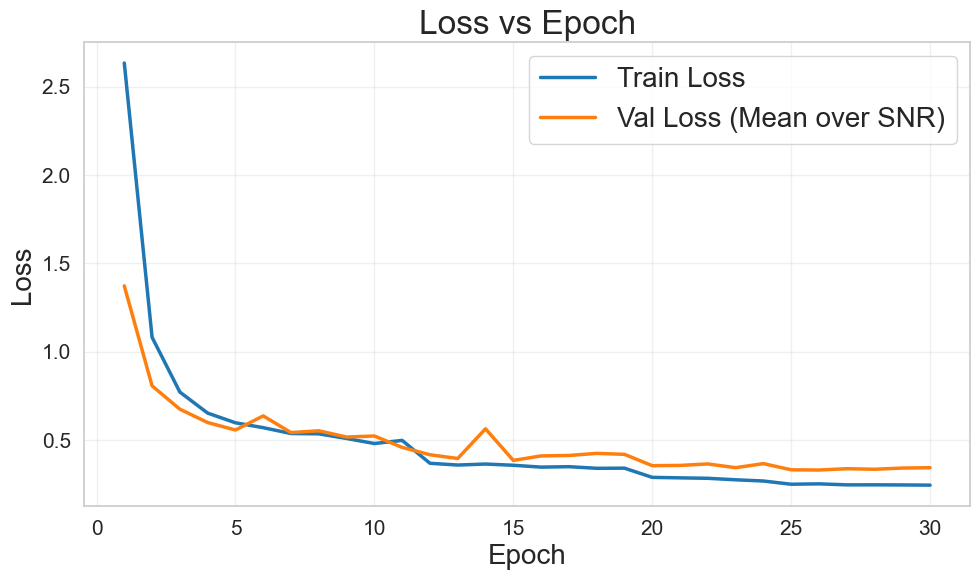

In [187]:
# Plot Loss vs Epoch
fig_loss, ax_loss = plot_loss_vs_epoch(MODEL_HISTORY)
plt.show()

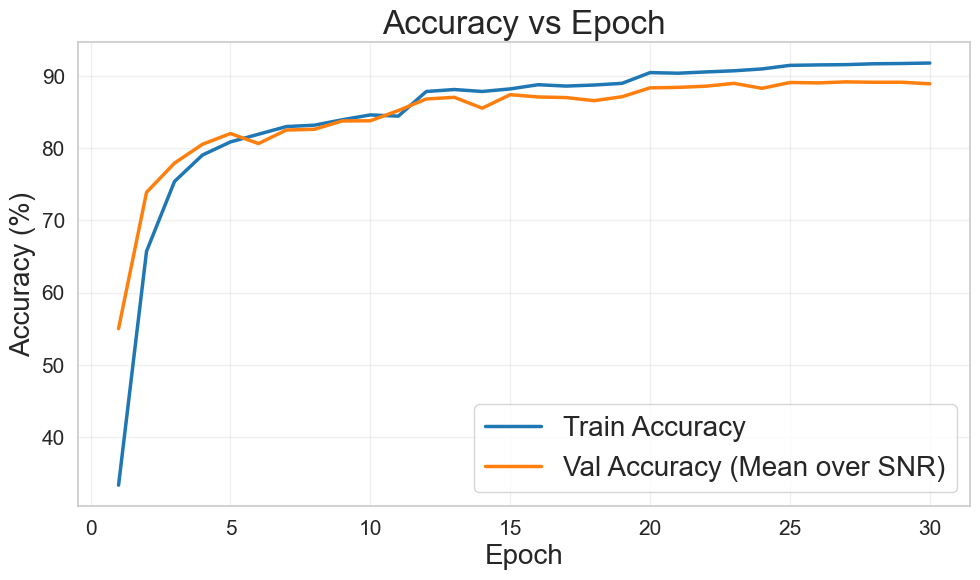

In [188]:
# Plot Accuracy vs Epoch
fig_acc, ax_acc = plot_accuracy_vs_epoch(MODEL_HISTORY)
plt.show()

### Static Rank Sweep

In [203]:
# Load per-sample results from CSV files
all_per_sample_dfs = {}
comb_names = ["comb_1"]  # Add other combination names if needed
for comb_name in comb_names:
    df = pd.read_csv(MODEL_DIR + f"per_sample_results_{comb_name}_golden.csv")
    all_per_sample_dfs[comb_name] = df

print(f"\nLoaded per-sample results from {MODEL_DIR}:")


Loaded per-sample results from /Users/christoffer/Documents/Thesis/thesis_project/model_runs/base/2025-12-14_18-48-50/:


In [204]:
df_for_viz = all_per_sample_dfs["comb_1"]
# get the length of a single validation set (samples per snr_eval, rank combo)
# Since samples are in the same order for all noise files, we can compute length from any group
len_single_val_set = df_for_viz.groupby(['val_set_id', 'snr_eval', 'rank']).size().iloc[0]
print(f"Length of single validation set: {len_single_val_set}")

# Assigning an ID to each sample based on its position within each (snr_eval, rank) group
# This ID is consistent across all val_set_id (noise files) since samples are loaded in same order
df_for_viz['id'] = df_for_viz.groupby(['snr_eval', 'rank']).cumcount() % len_single_val_set

# Verify: each (id, snr_eval, rank) should have exactly NUMBER_OF_VAL_SETS rows (one per noise file)
print(f"Unique noise files: {df_for_viz['noise_file'].unique().tolist()}")
print(f"Rows per (id, snr_eval, rank): {df_for_viz.groupby(['id', 'snr_eval', 'rank']).size().iloc[0]} (expected: {len(df_for_viz['val_set_id'].unique())})")

Length of single validation set: 4515
Unique noise files: ['doing_the_dishes.wav', 'dude_miaowing.wav', 'exercise_bike.wav', 'pink_noise.wav', 'running_tap.wav', 'white_noise.wav']
Rows per (id, snr_eval, rank): 6 (expected: 6)


In [205]:
def calculate_accuracy_by_rank(df, rank, snr_col='snr_eval', correct_col='correct', rank_col='rank'):
    """
    Calculates accuracy for each SNR, and micro/macro averages for a given rank.
    Args:
        df (pd.DataFrame): DataFrame containing columns for SNR, correct predictions, and rank.
        rank (int): The rank to filter on.
        snr_col (str): Column name for SNR values.
        correct_col (str): Column name for correct predictions (boolean).
        rank_col (str): Column name for rank.
    Returns:
        dict: Dictionary with per-SNR accuracy, micro avg, and macro avg.
    """
    filtered = df[df[rank_col] == rank]
    acc_per_snr = {}
    for snr, group in filtered.groupby(snr_col):
        acc = group[correct_col].mean()
        acc_per_snr[snr] = acc
    # Micro avg: accuracy over all samples
    micro_avg = filtered[correct_col].mean() if not filtered.empty else float('nan')
    # Macro avg: mean of per-SNR accuracies
    macro_avg = sum(acc_per_snr.values()) / len(acc_per_snr) if acc_per_snr else float('nan')
    return {
        'accuracy_per_snr': acc_per_snr,
        'micro_avg': micro_avg,
        'macro_avg': macro_avg
    }

In [206]:
calculate_accuracy_by_rank(df_for_viz, rank=18)

{'accuracy_per_snr': {-5.0: np.float64(0.7321520856404578),
  0.0: np.float64(0.823624953857512),
  5.0: np.float64(0.8697674418604651),
  10.0: np.float64(0.8935400516795866),
  15.0: np.float64(0.9037283130306386),
  inf: np.float64(0.9141011443337025)},
 'micro_avg': np.float64(0.8561523317337271),
 'macro_avg': np.float64(0.8561523317337271)}

In [207]:
def plot_accuracy_vs_rank(df, ranks=None, snr_col='snr_eval', correct_col='correct', rank_col='rank', 
                          figsize=(10, 6), mean=True):
    """
    Plots accuracy vs rank, either as mean (averaged over SNR) or individual SNR curves.
    
    Args:
        df (pd.DataFrame): DataFrame containing columns for SNR, correct predictions, and rank.
        ranks (list): List of ranks to plot. If None, uses all unique ranks in the data.
        snr_col (str): Column name for SNR values.
        correct_col (str): Column name for correct predictions (boolean).
        rank_col (str): Column name for rank.
        figsize (tuple): Figure size (width, height).
        mean (bool): If True, plot mean accuracy. If False, plot individual SNR curves.
    """
    if ranks is None:
        ranks = sorted(df[rank_col].unique())
    
    # Get all unique SNR values
    snrs = sorted(df[snr_col].unique())
    
    # Calculate accuracy for each rank and SNR
    acc_data = {snr: [] for snr in snrs}
    mean_acc = []
    
    for rank in ranks:
        result = calculate_accuracy_by_rank(df, rank, snr_col, correct_col, rank_col)
        acc_per_snr = result['accuracy_per_snr']
        
        # Store individual SNR accuracies
        for snr in snrs:
            acc_data[snr].append(acc_per_snr.get(snr, np.nan))
        
        # Store mean accuracy (macro average over SNRs)
        mean_acc.append(result['macro_avg'])
    
    # Calculate y-axis limits from all data (both mean and individual)
    all_values = mean_acc.copy()
    for snr in snrs:
        all_values.extend([v for v in acc_data[snr] if not np.isnan(v)])
    y_min = min(all_values) - 0.02
    y_max = max(all_values) + 0.02
    
    # Create plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot either mean or individual SNR curves
    if mean:
        ax.step(ranks, mean_acc, where='mid', color='black', linewidth=LINEWIDTH, label='Mean (over SNR)', zorder=10)
    else:
        for snr in snrs:
            ax.step(ranks, acc_data[snr], where='mid', alpha=0.7, linewidth=LINEWIDTH, label=f'SNR {snr} dB')
    
    ax.set_xlabel('Rank', fontsize=FONTSIZE_LABEL)
    ax.set_ylabel('Accuracy', fontsize=FONTSIZE_LABEL)
    ax.set_title('Accuracy vs Rank', fontsize=FONTSIZE_TITLE)
    ax.set_ylim(y_min, y_max)
    ax.tick_params(axis='both', labelsize=FONTSIZE_TICKS)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='lower right', fontsize=FONTSIZE_LEGEND)
    
    plt.tight_layout()
    return fig, ax 

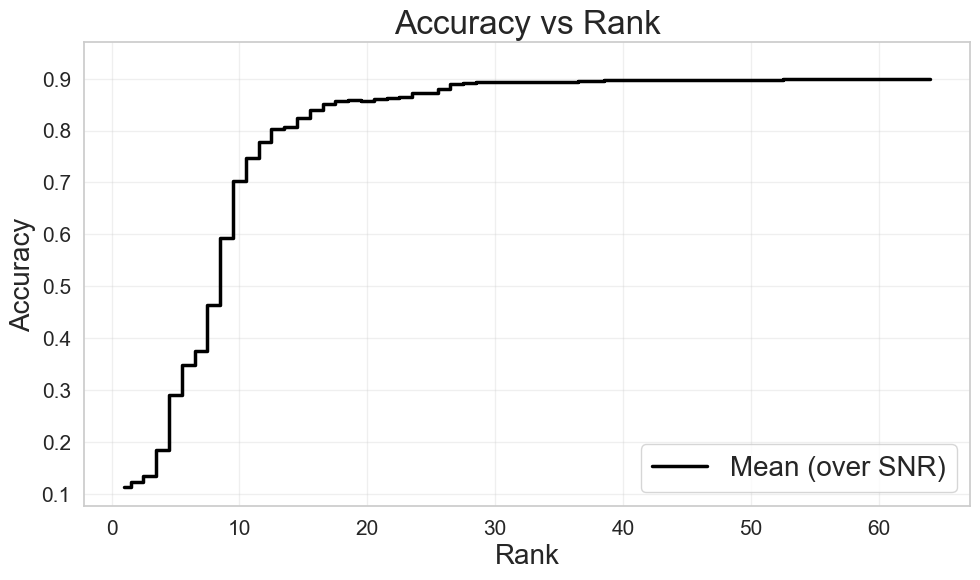

In [208]:
# Example usage: Plot accuracy vs rank
fig, ax = plot_accuracy_vs_rank(df_for_viz, mean=True)
plt.show()

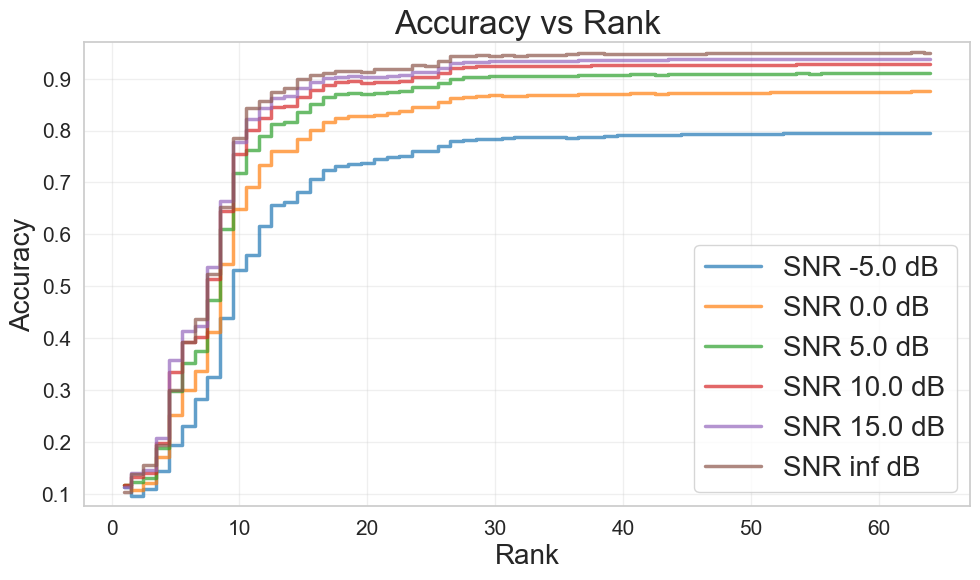

In [209]:
# Example usage: Plot accuracy vs rank
fig, ax = plot_accuracy_vs_rank(df_for_viz, mean=False)
plt.show()

### Static Rank Sweep

In [210]:
ranks_to_evaluate = [10,15,20,25,30]

In [220]:
def calculate_accuracy_by_rank_and_class(df, ranks, rank_col='rank', label_col='label', correct_col='correct'):
    """
    Calculates accuracy for each class at each rank, averaged over SNR and noise type.
    Also includes micro and macro averages over classes.
    
    Args:
        df (pd.DataFrame): DataFrame containing per-sample results.
        ranks (list): List of ranks to evaluate.
        rank_col (str): Column name for rank.
        label_col (str): Column name for class labels.
        correct_col (str): Column name for correct predictions (boolean).
    
    Returns:
        pd.DataFrame: DataFrame with ranks as rows and classes as columns, plus Micro and Macro columns.
    """
    # Get all unique classes
    classes = sorted(df[label_col].unique())
    
    # Initialize result dictionary
    result_data = {class_name: [] for class_name in classes}
    result_data['Micro Avg'] = []
    result_data['Macro Avg'] = []
    
    for rank in ranks:
        rank_df = df[df[rank_col] == rank]
        
        class_accuracies = []
        for class_name in classes:
            class_df = rank_df[rank_df[label_col] == class_name]
            # Calculate mean accuracy over all SNR and noise types
            accuracy = class_df[correct_col].mean() if not class_df.empty else 0.0
            result_data[class_name].append(accuracy)
            class_accuracies.append(accuracy)
        
        # Micro average: overall accuracy across all samples (regardless of class)
        micro_avg = rank_df[correct_col].mean() if not rank_df.empty else 0.0
        result_data['Micro Avg'].append(micro_avg)
        
        # Macro average: mean of per-class accuracies (each class weighted equally)
        macro_avg = np.mean(class_accuracies)
        result_data['Macro Avg'].append(macro_avg)
    
    # Create DataFrame with ranks as index
    result_df = pd.DataFrame(result_data, index=ranks)
    result_df.index.name = 'Rank'
    
    return result_df

In [221]:
# Calculate accuracy by rank and class
accuracy_table = calculate_accuracy_by_rank_and_class(df_for_viz, ranks_to_evaluate)

# Display the table (multiply by 100 for percentage)
print("Accuracy (%) by Rank and Class (averaged over SNR and noise type):\n")
print((accuracy_table * 100).round(2))

Accuracy (%) by Rank and Class (averaged over SNR and noise type):

      SILENCE  UNKNOWN   down     go   left     no    off     on  right  \
Rank                                                                      
10      84.36    49.27  58.32  43.72  76.20  82.60  86.49  87.42  45.71   
15      80.95    63.46  88.40  64.36  89.09  91.06  88.15  90.13  77.17   
20      79.47    68.68  90.54  80.93  90.97  90.98  86.60  91.99  82.88   
25      81.36    71.87  90.33  85.01  90.96  90.74  86.77  91.72  86.24   
30      99.38    74.97  91.34  85.69  91.68  90.20  84.47  91.86  88.84   

       stop     up    yes  Micro Avg  Macro Avg  
Rank                                             
10    65.48  78.91  83.68      70.26      70.18  
15    83.83  83.79  90.02      82.45      82.53  
20    88.93  84.94  93.37      85.73      85.86  
25    89.86  86.60  95.60      87.14      87.25  
30    89.86  87.89  95.66      89.32      89.32  


In [213]:
# Compare: Average across classes from table vs. Mean from plot
print("Comparison of averaging methods:\n")
print(f"{'Rank':<6} {'Table Avg (over classes)':<30} {'Plot Mean (over SNRs)':<30}")
print("-" * 70)

for rank in ranks_to_evaluate:
    # Average across classes from the table
    table_avg = accuracy_table.loc[rank].mean()
    
    # Mean from the plot (macro avg over SNRs)
    plot_mean = calculate_accuracy_by_rank(df_for_viz, rank)['macro_avg']
    
    print(f"{rank:<6} {table_avg*100:>28.2f}% {plot_mean*100:>28.2f}%")

Comparison of averaging methods:

Rank   Table Avg (over classes)       Plot Mean (over SNRs)         
----------------------------------------------------------------------
10                            70.18%                        70.26%
15                            82.53%                        82.45%
20                            85.86%                        85.73%
25                            87.25%                        87.14%
30                            89.32%                        89.32%


In [216]:
# Simple example showing why the two averages differ
print("Simple Example:\n")
print("Suppose we have 2 classes (A, B) and 2 SNR levels (Low, High)")
print("With the following accuracies:\n")

# Create example data
example_data = {
    'Class': ['A', 'A', 'B', 'B'],
    'SNR': ['Low', 'High', 'Low', 'High'],
    'Accuracy': [0.8, 0.9, 0.6, 0.7]
}
example_df = pd.DataFrame(example_data)
print(example_df.to_string(index=False))

print("\n" + "="*60)

# Method 1: Average over classes (like our table)
print("\nMethod 1 - Average over Classes (Table method):")
print("  Class A avg: (0.8 + 0.9) / 2 = 0.85")
print("  Class B avg: (0.6 + 0.7) / 2 = 0.65")
print("  Final: (0.85 + 0.65) / 2 = 0.75")
class_avg = example_df.groupby('Class')['Accuracy'].mean().mean()
print(f"  Result: {class_avg:.2f}")

print("\nMethod 2 - Average over SNRs (Plot method):")
print("  Low SNR avg: (0.8 + 0.6) / 2 = 0.70")
print("  High SNR avg: (0.9 + 0.7) / 2 = 0.80")
print("  Final: (0.70 + 0.80) / 2 = 0.75")
snr_avg = example_df.groupby('SNR')['Accuracy'].mean().mean()
print(f"  Result: {snr_avg:.2f}")

print("\n" + "="*60)
print("In this balanced case, both methods give the same result!")

print("\n\nNow let's add unbalanced samples:\n")
# Unbalanced example
unbalanced_data = {
    'Class': ['A', 'A', 'A', 'A', 'B', 'B'],  # Class A has 4 samples, B has 2
    'SNR': ['Low', 'Low', 'High', 'High', 'Low', 'High'],
    'Accuracy': [0.8, 0.8, 0.9, 0.9, 0.6, 0.7]
}
unbalanced_df = pd.DataFrame(unbalanced_data)
print(unbalanced_df.to_string(index=False))

print("\nMethod 1 - Average over Classes:")
print("  Class A avg: (0.8 + 0.8 + 0.9 + 0.9) / 4 = 0.85")
print("  Class B avg: (0.6 + 0.7) / 2 = 0.65")
print("  Final: (0.85 + 0.65) / 2 = 0.75  (each class weighted equally)")
class_avg_unbal = unbalanced_df.groupby('Class')['Accuracy'].mean().mean()
print(f"  Result: {class_avg_unbal:.4f}")

print("\nMethod 2 - Average over SNRs:")
print("  Low SNR avg: (0.8 + 0.8 + 0.6) / 3 = 0.7333...")
print("  High SNR avg: (0.9 + 0.9 + 0.7) / 3 = 0.8333...")
print("  Final: (0.7333... + 0.8333...) / 2 = 0.7833...  (each SNR weighted equally)")
snr_avg_unbal = unbalanced_df.groupby('SNR')['Accuracy'].mean().mean()
print(f"  Result: {snr_avg_unbal:.4f}")

print("\n" + "="*60)
print(f"Difference: {abs(class_avg_unbal - snr_avg_unbal):.4f}")
print("\nThe methods differ when sample distribution is unbalanced!")

Simple Example:

Suppose we have 2 classes (A, B) and 2 SNR levels (Low, High)
With the following accuracies:

Class  SNR  Accuracy
    A  Low       0.8
    A High       0.9
    B  Low       0.6
    B High       0.7


Method 1 - Average over Classes (Table method):
  Class A avg: (0.8 + 0.9) / 2 = 0.85
  Class B avg: (0.6 + 0.7) / 2 = 0.65
  Final: (0.85 + 0.65) / 2 = 0.75
  Result: 0.75

Method 2 - Average over SNRs (Plot method):
  Low SNR avg: (0.8 + 0.6) / 2 = 0.70
  High SNR avg: (0.9 + 0.7) / 2 = 0.80
  Final: (0.70 + 0.80) / 2 = 0.75
  Result: 0.75

In this balanced case, both methods give the same result!


Now let's add unbalanced samples:

Class  SNR  Accuracy
    A  Low       0.8
    A  Low       0.8
    A High       0.9
    A High       0.9
    B  Low       0.6
    B High       0.7

Method 1 - Average over Classes:
  Class A avg: (0.8 + 0.8 + 0.9 + 0.9) / 4 = 0.85
  Class B avg: (0.6 + 0.7) / 2 = 0.65
  Final: (0.85 + 0.65) / 2 = 0.75  (each class weighted equally)
  Result

In [217]:
# Let's examine what we actually do with the repeated samples
print("Understanding the data structure:\n")

# Check how many times each sample appears
sample_counts = df_for_viz.groupby(['id', 'rank']).size()
print(f"Each sample at a given rank appears {sample_counts.iloc[0]} times")

# Check unique SNR and noise values
unique_snrs = df_for_viz['snr_eval'].nunique()
unique_noise = df_for_viz['val_set_id'].nunique()
print(f"Unique SNR levels: {unique_snrs}")
print(f"Unique noise files: {unique_noise}")
print(f"Expected appearances per sample: {unique_snrs} × {unique_noise} = {unique_snrs * unique_noise}")

print("\n" + "="*70)
print("\nWhat we calculated:\n")

print("For the PLOT (Mean over SNR):")
print("  1. For each SNR level, calculate accuracy (mean of 'correct' for that rank+SNR)")
print("     → This includes all samples × all noise files at that SNR")
print("  2. Average these per-SNR accuracies (macro average over SNR)")
print("     → Each SNR level gets equal weight (1/6)")

print("\nFor the TABLE (Accuracy by class):")
print("  1. Filter to rows matching (rank, class)")
print("     → Includes all samples of that class × all SNR × all noise files")
print("  2. Calculate mean of 'correct' column")
print("     → Each row (sample×SNR×noise combo) gets equal weight")

print("\n" + "="*70)
print("\nKey point:")
print("We treat each (sample, SNR, noise_file) combination as an independent")
print("prediction. A sample that appears 36 times contributes 36 predictions.")
print("We don't first average per-sample, then average across samples.")

Understanding the data structure:

Each sample at a given rank appears 36 times
Unique SNR levels: 6
Unique noise files: 6
Expected appearances per sample: 6 × 6 = 36


What we calculated:

For the PLOT (Mean over SNR):
  1. For each SNR level, calculate accuracy (mean of 'correct' for that rank+SNR)
     → This includes all samples × all noise files at that SNR
  2. Average these per-SNR accuracies (macro average over SNR)
     → Each SNR level gets equal weight (1/6)

For the TABLE (Accuracy by class):
  1. Filter to rows matching (rank, class)
     → Includes all samples of that class × all SNR × all noise files
  2. Calculate mean of 'correct' column
     → Each row (sample×SNR×noise combo) gets equal weight


Key point:
We treat each (sample, SNR, noise_file) combination as an independent
prediction. A sample that appears 36 times contributes 36 predictions.
We don't first average per-sample, then average across samples.


In [218]:
# Micro vs Macro averaging for the PLOT
print("Micro vs Macro Averaging for Mean over SNR:\n")
print("="*70)

# Let's check for a specific rank
test_rank = 15
result = calculate_accuracy_by_rank(df_for_viz, test_rank)

print(f"\nFor Rank {test_rank}:\n")

print("MACRO average (current approach):")
print(f"  - Calculate accuracy at each SNR level")
print(f"  - Then average those 6 values")
print(f"  - Each SNR level gets equal weight (1/6)")
print(f"  - Result: {result['macro_avg']*100:.2f}%")

print("\nMICRO average (alternative):")
print(f"  - Take all samples across all SNR levels")
print(f"  - Calculate overall accuracy")
print(f"  - Each sample×SNR×noise combination gets equal weight")
print(f"  - Result: {result['micro_avg']*100:.2f}%")

print("\n" + "="*70)

# Check if they're the same across all ranks
print("\nComparison across all ranks:")
print(f"{'Rank':<6} {'Macro (equal SNR weight)':<30} {'Micro (equal sample weight)':<30} {'Difference':<15}")
print("-" * 85)

for rank in [10, 15, 20, 25, 30]:
    result = calculate_accuracy_by_rank(df_for_viz, rank)
    macro = result['macro_avg'] * 100
    micro = result['micro_avg'] * 100
    diff = abs(macro - micro)
    print(f"{rank:<6} {macro:>28.2f}% {micro:>28.2f}% {diff:>13.2f}%")

print("\n" + "="*70)
print("\nInterpretation:")
print("- MACRO: Treats each SNR condition as equally important")
print("          (Good if you want balanced reporting across noise levels)")
print("- MICRO: Overall accuracy across all test cases")
print("          (Good if you want aggregate performance)")
print("\nSince we have balanced data (same # samples per SNR), both are identical!")

Micro vs Macro Averaging for Mean over SNR:


For Rank 15:

MACRO average (current approach):
  - Calculate accuracy at each SNR level
  - Then average those 6 values
  - Each SNR level gets equal weight (1/6)
  - Result: 82.45%

MICRO average (alternative):
  - Take all samples across all SNR levels
  - Calculate overall accuracy
  - Each sample×SNR×noise combination gets equal weight
  - Result: 82.45%


Comparison across all ranks:
Rank   Macro (equal SNR weight)       Micro (equal sample weight)    Difference     
-------------------------------------------------------------------------------------
10                            70.26%                        70.26%          0.00%
15                            82.45%                        82.45%          0.00%
20                            85.73%                        85.73%          0.00%
25                            87.14%                        87.14%          0.00%
30                            89.32%                        89

In [219]:
# Check if we have balanced samples across classes
print("Sample Distribution Across Classes:\n")
print("="*70)

# For a specific rank, check unique samples per class
test_rank = 15

# Count unique samples (id) per class at this rank
# Remember: each sample appears 36 times (6 SNR × 6 noise files)
rank_df = df_for_viz[df_for_viz['rank'] == test_rank]

print(f"For Rank {test_rank}:\n")

# Count total rows per class
rows_per_class = rank_df['label'].value_counts().sort_index()
print("Total rows (sample×SNR×noise combinations) per class:")
print(rows_per_class)
print()

# Count unique samples per class
samples_per_class = rank_df.groupby('label')['id'].nunique().sort_index()
print("Unique samples per class:")
print(samples_per_class)
print()

print("="*70)
print("\nAnalysis:")
is_balanced = samples_per_class.nunique() == 1
if is_balanced:
    print(f"✓ Classes ARE balanced - all have {samples_per_class.iloc[0]} unique samples")
else:
    print(f"✗ Classes are NOT balanced:")
    print(f"  Min samples: {samples_per_class.min()}")
    print(f"  Max samples: {samples_per_class.max()}")
    print(f"  Difference: {samples_per_class.max() - samples_per_class.min()}")
    
print("\nImplication for TABLE averaging:")
if is_balanced:
    print("  Since classes are balanced, micro and macro averaging")
    print("  over classes would give the same result.")
else:
    print("  Since classes are UNbalanced, micro and macro averaging")
    print("  over classes would give DIFFERENT results.")
    print("  - Micro: weights by actual sample count")
    print("  - Macro: treats each class equally")

Sample Distribution Across Classes:

For Rank 15:

Total rows (sample×SNR×noise combinations) per class:
label
SILENCE    14616
UNKNOWN    14616
down       13572
go         13392
left       12672
no         14616
off        13428
on         13068
right      13068
stop       12600
up         12600
yes        14292
Name: count, dtype: int64

Unique samples per class:
label
SILENCE    406
UNKNOWN    406
down       377
go         372
left       352
no         406
off        373
on         363
right      363
stop       350
up         350
yes        397
Name: id, dtype: int64


Analysis:
✗ Classes are NOT balanced:
  Min samples: 350
  Max samples: 406
  Difference: 56

Implication for TABLE averaging:
  Since classes are UNbalanced, micro and macro averaging
  over classes would give DIFFERENT results.
  - Micro: weights by actual sample count
  - Macro: treats each class equally


In [222]:
# Demonstrate macro vs micro with extreme example
print("Why Macro can be misleading:\n")
print("="*70)

# Create hypothetical example
print("\nImagine we have 3 classes with different sample sizes and accuracies:\n")

extreme_example = pd.DataFrame({
    'Class': ['A (large)', 'A (large)', 'B (medium)', 'B (medium)', 'C (tiny)', 'C (tiny)'],
    'Samples': [1000, 1000, 100, 100, 10, 10],
    'Accuracy': [0.85, 0.85, 0.80, 0.80, 0.95, 0.95]
})

print("Class A: 1000 samples, 85% accuracy")
print("Class B: 100 samples, 80% accuracy")
print("Class C: 10 samples, 95% accuracy")

print("\nMacro average (equal class weight):")
macro_example = (0.85 + 0.80 + 0.95) / 3
print(f"  (85% + 80% + 95%) / 3 = {macro_example*100:.2f}%")
print("  → Class C (tiny) gets same weight as Class A (large)!")

print("\nMicro average (weighted by sample count):")
total_correct = (1000*0.85 + 100*0.80 + 10*0.95)
total_samples = (1000 + 100 + 10)
micro_example = total_correct / total_samples
print(f"  (850 + 80 + 9.5) / 1110 = {micro_example*100:.2f}%")
print("  → Reflects actual overall performance")

print("\n" + "="*70)
print(f"Difference: {abs(macro_example - micro_example)*100:.2f} percentage points!")

print("\nIn your data:")
print(f"  Class imbalance: {samples_per_class.min()} to {samples_per_class.max()} samples")
print(f"  Difference: Only 0.08-0.27% between micro and macro")
print(f"  → Your imbalance is mild, so the difference is small")

print("\nWhich to use?")
print("  - Macro: When you care about all classes equally (e.g., rare words matter)")
print("  - Micro: When you care about overall accuracy (majority classes dominate)")

Why Macro can be misleading:


Imagine we have 3 classes with different sample sizes and accuracies:

Class A: 1000 samples, 85% accuracy
Class B: 100 samples, 80% accuracy
Class C: 10 samples, 95% accuracy

Macro average (equal class weight):
  (85% + 80% + 95%) / 3 = 86.67%
  → Class C (tiny) gets same weight as Class A (large)!

Micro average (weighted by sample count):
  (850 + 80 + 9.5) / 1110 = 84.64%
  → Reflects actual overall performance

Difference: 2.03 percentage points!

In your data:
  Class imbalance: 350 to 406 samples
  Difference: Only 0.08-0.27% between micro and macro
  → Your imbalance is mild, so the difference is small

Which to use?
  - Macro: When you care about all classes equally (e.g., rare words matter)
  - Micro: When you care about overall accuracy (majority classes dominate)


In [223]:
# Verify that Micro Avg from table matches Plot Mean over SNRs
print("Verification: Table Micro Avg vs Plot Mean over SNRs\n")
print("="*70)

print(f"{'Rank':<6} {'Table Micro Avg':<20} {'Plot Mean (SNRs)':<20} {'Difference':<15}")
print("-" * 70)

for rank in ranks_to_evaluate:
    # Micro avg from table (overall accuracy for this rank)
    table_micro = accuracy_table.loc[rank, 'Micro Avg']
    
    # Plot mean (macro avg over SNRs)
    plot_mean = calculate_accuracy_by_rank(df_for_viz, rank)['macro_avg']
    
    diff = abs(table_micro - plot_mean) * 100
    
    print(f"{rank:<6} {table_micro*100:>18.2f}% {plot_mean*100:>18.2f}% {diff:>13.4f}%")

print("\n" + "="*70)
print("\nWhy they match:")
print("  - Table Micro Avg: Overall accuracy across all samples for this rank")
print("  - Plot Mean: Macro average over SNRs (each SNR weighted equally)")
print("  - Since data is BALANCED across SNRs (same # samples per SNR),")
print("    macro over SNRs = micro overall!")
print("\nSo:")
print("  - Table Micro Avg ≈ Plot Mean (both ~70.26% for rank 10)")
print("  - Table Macro Avg ≠ Plot Mean (70.18% vs 70.26% - different averaging)")

Verification: Table Micro Avg vs Plot Mean over SNRs

Rank   Table Micro Avg      Plot Mean (SNRs)     Difference     
----------------------------------------------------------------------
10                  70.26%              70.26%        0.0000%
15                  82.45%              82.45%        0.0000%
20                  85.73%              85.73%        0.0000%
25                  87.14%              87.14%        0.0000%
30                  89.32%              89.32%        0.0000%


Why they match:
  - Table Micro Avg: Overall accuracy across all samples for this rank
  - Plot Mean: Macro average over SNRs (each SNR weighted equally)
  - Since data is BALANCED across SNRs (same # samples per SNR),
    macro over SNRs = micro overall!

So:
  - Table Micro Avg ≈ Plot Mean (both ~70.26% for rank 10)
  - Table Macro Avg ≠ Plot Mean (70.18% vs 70.26% - different averaging)


In [224]:
def calculate_accuracy_by_rank_and_noise(df, ranks, rank_col='rank', noise_col='noise_file', correct_col='correct'):
    """
    Calculates accuracy for each noise type at each rank, averaged over SNR and classes.
    Also includes micro and macro averages over noise types.
    
    Args:
        df (pd.DataFrame): DataFrame containing per-sample results.
        ranks (list): List of ranks to evaluate.
        rank_col (str): Column name for rank.
        noise_col (str): Column name for noise file/type.
        correct_col (str): Column name for correct predictions (boolean).
    
    Returns:
        pd.DataFrame: DataFrame with ranks as rows and noise types as columns, plus Micro and Macro columns.
    """
    # Get all unique noise types
    noise_types = sorted(df[noise_col].unique())
    
    # Initialize result dictionary
    result_data = {noise_type: [] for noise_type in noise_types}
    result_data['Micro Avg'] = []
    result_data['Macro Avg'] = []
    
    for rank in ranks:
        rank_df = df[df[rank_col] == rank]
        
        noise_accuracies = []
        for noise_type in noise_types:
            noise_df = rank_df[rank_df[noise_col] == noise_type]
            # Calculate mean accuracy over all SNR and classes
            accuracy = noise_df[correct_col].mean() if not noise_df.empty else 0.0
            result_data[noise_type].append(accuracy)
            noise_accuracies.append(accuracy)
        
        # Micro average: overall accuracy across all samples (regardless of noise type)
        micro_avg = rank_df[correct_col].mean() if not rank_df.empty else 0.0
        result_data['Micro Avg'].append(micro_avg)
        
        # Macro average: mean of per-noise accuracies (each noise type weighted equally)
        macro_avg = np.mean(noise_accuracies)
        result_data['Macro Avg'].append(macro_avg)
    
    # Create DataFrame with ranks as index
    result_df = pd.DataFrame(result_data, index=ranks)
    result_df.index.name = 'Rank'
    
    return result_df

In [225]:
# Calculate and display accuracy by rank and noise type
accuracy_by_noise = calculate_accuracy_by_rank_and_noise(df_for_viz, ranks_to_evaluate)

# Display the table (multiply by 100 for percentage)
print("Accuracy (%) by Rank and Noise Type (averaged over SNR and classes):\n")
print((accuracy_by_noise * 100).round(2))

Accuracy (%) by Rank and Noise Type (averaged over SNR and classes):

      doing_the_dishes.wav  dude_miaowing.wav  exercise_bike.wav  \
Rank                                                               
10                   65.33              66.59              70.13   
15                   80.20              75.95              83.57   
20                   83.19              79.19              86.64   
25                   86.17              80.95              86.79   
30                   87.17              89.43              88.79   

      pink_noise.wav  running_tap.wav  white_noise.wav  Micro Avg  Macro Avg  
Rank                                                                          
10             73.66            73.71            72.12      70.26      70.26  
15             84.35            85.85            84.75      82.45      82.45  
20             88.45            88.95            87.94      85.73      85.73  
25             89.80            89.94            89.17    

### Export Tables to LaTeX

In [228]:
# Convert accuracy by class table to LaTeX with custom formatting
def table_to_custom_latex(df, caption, label, col_mapping=None):
    """
    Create a custom LaTeX table with specific formatting.
    
    Args:
        df: DataFrame with data (already in percentages)
        caption: Table caption
        label: Table label
        col_mapping: Dict to rename/reorder columns {old_name: new_name}
    """
    # Reorder and rename columns if mapping provided
    if col_mapping:
        cols_ordered = [col for col in col_mapping.keys() if col in df.columns]
        df_formatted = df[cols_ordered].copy()
        df_formatted.columns = [col_mapping[col] for col in cols_ordered]
    else:
        df_formatted = df.copy()
    
    # Build LaTeX string
    latex = r"\begin{table}[ht]" + "\n"
    latex += r"\centering" + "\n"
    latex += f"\\caption{{{caption}}}\n"
    latex += f"\\label{{{label}}}\n\n"
    latex += r"\setlength{\tabcolsep}{8pt}     % horizontal padding between columns" + "\n"
    latex += r"\renewcommand{\arraystretch}{1.1} % vertical spacing between rows" + "\n"
    latex += r"\resizebox{\textwidth}{!}{" + "\n"
    
    # Table header
    num_cols = len(df_formatted.columns) + 1  # +1 for Rank column
    latex += r"\begin{tabular}{" + "l" + "r" * (num_cols - 1) + "}\n"
    latex += r"\toprule" + "\n"
    
    # Column headers (centered)
    headers = [r"\multicolumn{1}{c}{Rank}"]
    for col in df_formatted.columns:
        # Add quotes around class names, but not for Micro/Macro Avg
        if col in ["Micro Avg", "Macro Avg"]:
            headers.append(f"\\multicolumn{{1}}{{c}}{{{col}}}")
        else:
            headers.append(f'\\multicolumn{{1}}{{c}}{{"{col}"}}')
    latex += " &\n".join(headers) + " \\\\\n"
    latex += r"\midrule" + "\n"
    
    # Data rows
    for rank_idx in df_formatted.index:
        row_values = [str(rank_idx)]
        for val in df_formatted.loc[rank_idx]:
            row_values.append(f"{val:.2f}")
        latex += " & ".join(row_values) + " \\\\\n"
    
    latex += r"\bottomrule" + "\n"
    latex += r"\end{tabular}" + "\n"
    latex += "}\n"
    latex += r"\end{table}" + "\n"
    
    return latex


# Define column mapping: original column name -> display name
class_col_mapping = {
    # Spoken word classes (alphabetically)
    'down': 'down',
    'go': 'go',
    'left': 'left',
    'no': 'no',
    'off': 'off',
    'on': 'on',
    'right': 'right',
    'stop': 'stop',
    'up': 'up',
    'yes': 'yes',
    # Special classes
    'SILENCE': 'SIL',
    'UNKNOWN': 'UNK',
    # Averages
    'Micro Avg': 'Micro Avg',
    'Macro Avg': 'Macro Avg'
}

latex_class = table_to_custom_latex(
    accuracy_table * 100,
    caption="Per-class accuracy at different ranks, averaged across all noise conditions",
    label="tab:accuracy_by_class",
    col_mapping=class_col_mapping
)

print("Accuracy by Class LaTeX table:")
print(latex_class)

# Optionally save to file
# with open('accuracy_by_class.tex', 'w') as f:
#     f.write(latex_class)

Accuracy by Class LaTeX table:
\begin{table}[ht]
\centering
\caption{Per-class accuracy at different ranks, averaged across all noise conditions}
\label{tab:accuracy_by_class}

\setlength{\tabcolsep}{8pt}     % horizontal padding between columns
\renewcommand{\arraystretch}{1.1} % vertical spacing between rows
\resizebox{\textwidth}{!}{
\begin{tabular}{lrrrrrrrrrrrrrr}
\toprule
\multicolumn{1}{c}{Rank} &
\multicolumn{1}{c}{"down"} &
\multicolumn{1}{c}{"go"} &
\multicolumn{1}{c}{"left"} &
\multicolumn{1}{c}{"no"} &
\multicolumn{1}{c}{"off"} &
\multicolumn{1}{c}{"on"} &
\multicolumn{1}{c}{"right"} &
\multicolumn{1}{c}{"stop"} &
\multicolumn{1}{c}{"up"} &
\multicolumn{1}{c}{"yes"} &
\multicolumn{1}{c}{"SIL"} &
\multicolumn{1}{c}{"UNK"} &
\multicolumn{1}{c}{Micro Avg} &
\multicolumn{1}{c}{Macro Avg} \\
\midrule
10 & 58.32 & 43.72 & 76.20 & 82.60 & 86.49 & 87.42 & 45.71 & 65.48 & 78.91 & 83.68 & 84.36 & 49.27 & 70.26 & 70.18 \\
15 & 88.40 & 64.36 & 89.09 & 91.06 & 88.15 & 90.13 & 77.17 & 83

In [230]:
# Convert accuracy by noise type table to LaTeX with custom formatting
# Define column mapping for noise types
noise_col_mapping = {
    'doing_the_dishes.wav': 'doing_the_dishes',
    'dude_miaowing.wav': 'dude_miaowing',
    'exercise_bike.wav': 'exercise_bike',
    'pink_noise.wav': 'pink_noise',
    'running_tap.wav': 'running_tap',
    'white_noise.wav': 'white_noise',
    'Micro Avg': 'Micro Avg',
    'Macro Avg': 'Macro Avg'
}

latex_noise = table_to_custom_latex(
    accuracy_by_noise * 100,
    caption="Per-noise accuracy at different ranks, averaged across SNR levels and classes",
    label="tab:accuracy_by_noise",
    col_mapping=noise_col_mapping
)

print("Accuracy by Noise Type LaTeX table:")
print(latex_noise)

# Optionally save to file
# with open('accuracy_by_noise.tex', 'w') as f:
#     f.write(latex_noise)

Accuracy by Noise Type LaTeX table:
\begin{table}[ht]
\centering
\caption{Per-noise accuracy at different ranks, averaged across SNR levels and classes}
\label{tab:accuracy_by_noise}

\setlength{\tabcolsep}{8pt}     % horizontal padding between columns
\renewcommand{\arraystretch}{1.1} % vertical spacing between rows
\resizebox{\textwidth}{!}{
\begin{tabular}{lrrrrrrrr}
\toprule
\multicolumn{1}{c}{Rank} &
\multicolumn{1}{c}{"doing_the_dishes"} &
\multicolumn{1}{c}{"dude_miaowing"} &
\multicolumn{1}{c}{"exercise_bike"} &
\multicolumn{1}{c}{"pink_noise"} &
\multicolumn{1}{c}{"running_tap"} &
\multicolumn{1}{c}{"white_noise"} &
\multicolumn{1}{c}{Micro Avg} &
\multicolumn{1}{c}{Macro Avg} \\
\midrule
10 & 65.33 & 66.59 & 70.13 & 73.66 & 73.71 & 72.12 & 70.26 & 70.26 \\
15 & 80.20 & 75.95 & 83.57 & 84.35 & 85.85 & 84.75 & 82.45 & 82.45 \\
20 & 83.19 & 79.19 & 86.64 & 88.45 & 88.95 & 87.94 & 85.73 & 85.73 \\
25 & 86.17 & 80.95 & 86.79 & 89.80 & 89.94 & 89.17 & 87.14 & 87.14 \\
30 & 87.17 & 